# 03. Modelagem supervisionada

**Fase CRISP-DM:** 4, *Modeling*.
**Entregáveis:** desenho de teste, modelos treinados com parâmetros e seeds, avaliação técnica comparativa e justificativa da escolha.

Este notebook narra as decisões e lê os artefatos. O treino mora em [`src/modeling/`](../src/modeling), as métricas em [`src/evaluation/`](../src/evaluation), e todo número aqui vem de `reports/metrics/`, gravado por:

```
python -m src.modeling.train comparacao     # cv_modelos.csv
python -m src.modeling.train tuning         # tuning_lgbm.csv + hiperparametros_campeao.json
python -m src.modeling.train campeao        # models/campeao.joblib + campeao*.csv/json
python -m src.evaluation.rigor              # rigor_*.csv
```

| Pergunta | Decisão que ela fecha |
|---|---|
| Quanto vale a regra de uma variável **neste** desenho de validação? | qual é a barra que o modelo precisa superar |
| Boosting supera floresta o bastante para pagar 8x o tempo? | quem é o campeão |
| A busca de hiperparâmetros entrega ganho maior que o desvio entre folds? | usar o resultado da busca ou os parâmetros de partida |
| A calibração isotônica melhora o Brier fora do próprio ajuste? | serializar o modelo calibrado ou o cru |
| O sinal sobrevive à permutação, à troca de região e à troca de ano? | publicar o modelo ou reportar que não há o que publicar |
| Em quais fatias da coorte o número agregado mente? | o que precisa ir estratificado em todo relatório |

A expectativa foi fixada antes de treinar: **ROC-AUC 0,65 ± 0,03**. Acima de 0,80 seria motivo para procurar vazamento, não para comemorar — esta base não tem nenhuma variável sobre a criança.

> **Status de validação:** evidência retrospectiva e exploratória. A seleção supervisionada de atributos consultou a coorte inteira de 2024, então a reserva de teste não é independente dessa seleção, e não há validação temporal do campeão. O status está fixado em `src/evaluation/protocolo.py`; os limites do trabalho estão no `README.md` e a proveniência temporal de cada atributo em `reports/contrato_temporal.md`.


In [1]:
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

from src import config, eda
from src.data import loader
from src.evaluation import metrics as mt, rigor
from src.modeling import campeao, split, train, tuning
from src.preprocessing import pipeline as pl
from src.visualization import plots_modelagem as plots

eda.aplicar_estilo()
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

print("interpretador", sys.executable)
print("RANDOM_STATE ", config.RANDOM_STATE)

interpretador C:\Users\Vyctor\Documents\pos-tech\fase-3\Fase3_TechChallenge-Predicao-Inteligencia-Analitica-para-Alfabetizacao-no-Brasil\.venv\Scripts\python.exe
RANDOM_STATE  42


---
## 1. O desenho de validação

**Pergunta:** como separar treino e teste sem deixar o modelo memorizar território?
**Decisão:** a unidade do split, e contra qual prevalência cada métrica é lida.

As features que carregam sinal são todas municipais. Num split aleatório, alunos do mesmo município cairiam dos dois lados e o modelo reencontraria no teste um nível que já viu no treino — memorização, não generalização. Agrupando por `id_municipio`, todo município do teste é inédito.

In [2]:
dados = loader.carregar_dataset_modelagem()
X, y, grupos = pl.separar_X_y(dados)
dev, teste = split.separar_desenvolvimento_e_teste(grupos)
particoes = split.folds(y.iloc[dev].reset_index(drop=True), grupos.iloc[dev].reset_index(drop=True))

resumo_split = pd.DataFrame(
    [
        {"conjunto": nome, "alunos": len(pos), "%_alunos": len(pos) / len(y),
         "municipios": grupos.iloc[pos].nunique(), "prevalencia": y.iloc[pos].mean()}
        for nome, pos in (("desenvolvimento", dev), ("teste", teste))
    ]
)
print(resumo_split.round(4).to_string(index=False))
print("\nmunicipios em comum entre os dois lados:", len(set(grupos.iloc[dev]) & set(grupos.iloc[teste])))
print("folds de validacao:", [len(v) for _, v in particoes])
print("features em X:", len(pl.FEATURES_MODELO), "| colunas proibidas em X:", len(set(X.columns) & set(config.COLS_PROIBIDAS)))

       conjunto  alunos  %_alunos  municipios  prevalencia
desenvolvimento 1521016    0.8213        4413       0.4067
          teste  330836    0.1787        1104       0.3812

municipios em comum entre os dois lados: 0
folds de validacao: [306521, 303581, 303651, 303569, 303694]
features em X: 20 | colunas proibidas em X: 0


**Achado 1, a partição de municípios não é a partição de alunos.** Vinte por cento dos municípios são 17,9% das linhas, e a prevalência do risco fica em **0,4067 no desenvolvimento contra 0,3812 no teste** — 2,5pp de diferença. Não é defeito do split: é a heterogeneidade territorial que ele existe para expor, já que os 1.104 municípios sorteados para o teste são, por acaso, um pouco melhores que a média. A consequência prática é que toda métrica de teste tem de ser lida contra a prevalência **do teste**, e não contra a global — um PR-AUC de 0,54 significa coisas diferentes contra 0,40 e contra 0,38.

---
## 2. Os dois pisos e os três candidatos

**Pergunta:** quanto vale, neste desenho, a regra "ranqueie os alunos pela taxa de alfabetização de 2023 do seu município"?
**Decisão:** qual é a barra real, e se algum modelo a supera além do ruído entre folds.

O diagnóstico media 0,654 para essa regra, mas noutro esquema de validação. Comparar contra aquele número seria comparar coisas diferentes, então ela foi reimplementada como estimador e passou pelos **mesmos cinco folds** que os candidatos.

                           modelo                                           papel  roc_auc  roc_auc_dp  pr_auc  pr_auc_dp     ks  brier  segundos
                  lightgbm_tunado            campeão com hiperparâmetros da busca   0.6611      0.0104  0.5519     0.0108 0.2332 0.2223     16.80
                    random_forest      não-linearidade e interações, sem boosting   0.6610      0.0102  0.5521     0.0089 0.2310 0.2224     88.70
                  lightgbm_padrao candidato a campeão, hiperparâmetros de partida   0.6589      0.0098  0.5492     0.0103 0.2294 0.2229     11.00
                 logistica_podada    linear interpretável, subconjunto de VIF < 3   0.6513      0.0113  0.5389     0.0108 0.2189 0.2246      2.00
heuristica_proficiencia_municipal        regra de uma variável, variante contínua   0.6388      0.0144  0.5255     0.0160 0.2035 0.2269      0.70
        heuristica_taxa_municipal            regra de uma variável — a barra real   0.6337      0.0135  0.5227     0.0150 0.

images/modelagem/01_comparacao_modelos.png


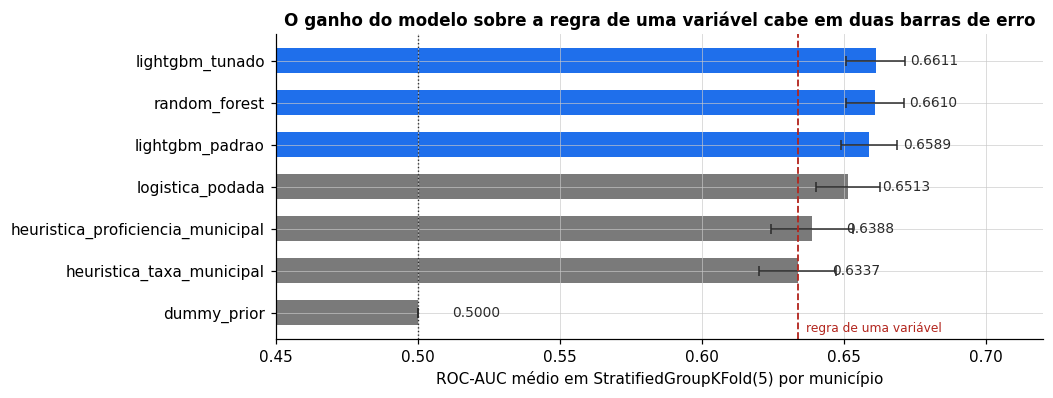

In [3]:
cv = pd.read_csv(config.DIR_METRICS / "cv_modelos.csv")
resumo = train.resumo_da_comparacao()
print(resumo.round(4).to_string(index=False))

fig = plots.plotar_comparacao_de_modelos(resumo)
print(plots.salvar_figura(fig, "01_comparacao_modelos"))

In [4]:
pareado = pd.read_csv(config.DIR_METRICS / "comparacao_pareada.csv")
print(pareado.round(5).to_string(index=False))

metrica                      base                       alternativo  n_folds  delta_medio  delta_dp  folds_a_favor  ic95_baixo  ic95_alto  t_nadeau_bengio  p_valor
roc_auc               dummy_prior         heuristica_taxa_municipal        5      0.13366   0.01352              5     0.10849    0.15884         14.74096  0.00012
roc_auc heuristica_taxa_municipal heuristica_proficiencia_municipal        5      0.00518   0.00200              5     0.00146    0.00890          3.86564  0.01806
roc_auc heuristica_taxa_municipal                  logistica_podada        5      0.01760   0.00723              5     0.00414    0.03106          3.63103  0.02214
roc_auc          logistica_podada                   lightgbm_padrao        5      0.00762   0.00294              5     0.00214    0.01310          3.86301  0.01810
roc_auc           lightgbm_padrao                   lightgbm_tunado        5      0.00223   0.00177              5    -0.00106    0.00552          1.88183  0.13300
roc_auc         

**Achado 2, a regra de uma variável vale 0,6337 aqui, não 0,654.** O número histórico foi medido noutro desenho; sob `StratifiedGroupKFold` por município a mesma regra cai para **0,6337 ± 0,0135**. É a barra correta, e é contra ela que tudo o mais é lido.

**Achado 3, o ganho existe e é pequeno.** O campeão entrega **0,6611 ± 0,0104**, ou **+0,0274** sobre a regra de uma variável, com IC95 de Nadeau-Bengio de [+0,0116; +0,0433] e p = 0,009. Vinte features de engenharia territorial, uma busca de hiperparâmetros e um GBM compram menos de três centésimos de AUC sobre uma linha de SQL. É pouco, e é o que a base permite: não há **nenhuma** variável sobre a criança — nem nível socioeconômico, nem cor/raça, nem idade, nem frequência. O que 0,66 mede é quanto o território determina o destino individual.

**Achado 4, floresta e boosting empatam, e o desempate é custo.** `RandomForest` marca 0,6610 e o LightGBM ajustado 0,6611, com delta pareado de −0,0002, IC95 [−0,0015; +0,0012] e p = 0,78 — estatisticamente indistinguíveis. A floresta leva **89 segundos por fold** contra 17 do boosting. O campeão é o LightGBM por custo computacional e por suporte nativo a SHAP na Etapa 5, não por vencer.

**Achado 5, a regressão logística sobre o subconjunto podado chega perto.** 0,6513 com oito colunas e VIF abaixo de 3, contra 0,6611 do campeão com vinte. A distância de 0,0098 é quase igual ao desvio entre folds. Um scorecard linear resolveria quase todo o problema, e é um argumento a considerar quando a explicabilidade for requisito duro.

---
## 3. A busca de hiperparâmetros

**Pergunta:** o espaço de busca do plano entrega ganho maior que o ruído entre folds?
**Decisão:** publicar os parâmetros da busca ou os de partida.

Quarenta configurações sorteadas, `StratifiedGroupKFold(5)` sobre 400 mil alunos de 1.277 municípios inteiros. A subamostra é de **municípios**, nunca de alunos: metade de um município no treino e metade na validação reintroduziria a memorização que o desenho evita.

In [5]:
busca = pd.read_csv(config.DIR_METRICS / "tuning_lgbm.csv").sort_values("roc_auc", ascending=False)
print(busca.head(5).round(4).to_string(index=False))
print("\namplitude da busca: %.4f a %.4f | desvio entre folds da melhor: %.4f"
      % (busca["roc_auc"].min(), busca["roc_auc"].max(), busca["roc_auc_dp"].iloc[0]))
print("\ndiagnostico de borda:")
print(tuning.diagnostico_de_borda().to_string(index=False))

 iteracao  roc_auc  roc_auc_dp  brier  segundos  colsample_bytree  learning_rate  max_depth  min_child_samples  n_estimators  num_leaves  reg_lambda  subsample
       22   0.6646      0.0276 0.2217      27.0            0.9633         0.0205          5               1126           883         104      9.8565     0.6968
       21   0.6643      0.0273 0.2217      20.2            0.7139         0.0112          4                 51           841         106      0.5148     0.7115
       39   0.6643      0.0277 0.2218      11.2            0.8685         0.0293          5                834           303          47      1.3662     0.8836
        5   0.6641      0.0281 0.2219      21.7            0.6064         0.0200         10               1501           708          22      0.3439     0.9637
        2   0.6640      0.0279 0.2220      23.7            0.9754         0.0100          8               1234           659          72      5.2476     0.7728

amplitude da busca: 0.6494 a 0.6646 | d

In [6]:
bordas = pd.read_csv(config.DIR_METRICS / "tuning_bordas.csv")
print(bordas.pivot_table(index="n_estimators", columns="reg_lambda", values="roc_auc").round(4).to_string())

reg_lambda    9.86    30.00   100.00
n_estimators                        
883           0.6646  0.6647  0.6647
1500          0.6636  0.6638  0.6638
2500          0.6627  0.6629  0.6628


**Achado 6, a busca inteira cabe dentro do ruído da própria amostra.** As 40 configurações vão de 0,6570 a 0,6646 — uma amplitude de 0,0076 —, e o desvio entre folds da melhor delas é **0,0276**. Ou seja, a distância entre a melhor e a pior configuração é um quarto da oscilação entre partições da mesma configuração. Remedido no desenvolvimento completo, o ganho sobre os hiperparâmetros de partida é de **+0,0022, com IC95 [−0,0011; +0,0055] e p = 0,13**: não é significante. Os parâmetros da busca ficam porque são os melhores disponíveis, não porque provaram ser melhores.

**Achado 7, dois parâmetros pararam na borda da grade, e a extensão não achou nada.** A busca escolheu o maior `n_estimators` (883) e o maior `reg_lambda` (9,86) que o espaço oferecia — o sinal clássico de grade curta demais. Esticando para 2.500 árvores e `reg_lambda` até 100: mais árvores **piora** (0,6646 → 0,6636 → 0,6627) e a regularização é plana até 100 (diferença de 1e-4 contra desvio de 0,028). A borda era cosmética. Vale registrar a forma do vencedor: `max_depth = 5` com `min_child_samples = 1.126` — a busca convergiu para um modelo raso e fortemente freado, coerente com um sinal que é de grupo e não de indivíduo.

---
## 4. Calibração e limiar

**Pergunta:** a isotônica melhora a probabilidade, e onde cortar o escore?
**Decisão:** serializar o modelo calibrado ou o cru, e qual limiar publicar.

A calibração importa porque as probabilidades viram, na Etapa 6, o ranking municipal de risco: `risco_municipal` é a média das probabilidades dentro do município. Um viés que se distribua de forma desigual entre territórios reordena o topo da lista — a parte que decide orçamento.

In [7]:
metricas = json.loads((config.DIR_METRICS / "campeao.json").read_text(encoding="utf-8"))
print("hiperparametros do campeao:")
print(json.dumps(metricas["hiperparametros"], indent=2))
print("\ncalibracao:", {k: (round(v, 5) if isinstance(v, float) else v) for k, v in metricas["calibracao"].items()})
print("\nlimiar:", metricas["limiar"])

hiperparametros do campeao:
{
  "n_estimators": 883,
  "num_leaves": 104,
  "max_depth": 5,
  "learning_rate": 0.020496381951116718,
  "min_child_samples": 1126,
  "subsample": 0.6968221086046001,
  "colsample_bytree": 0.9633063543866615,
  "reg_lambda": 9.856504541106007,
  "subsample_freq": 1,
  "n_jobs": -1,
  "verbose": -1
}

calibracao: {'brier_bruto': 0.22233, 'brier_calibrado': 0.22244, 'ganho_brier': -0.00011, 'aplicada': False, 'criterio': 'isotônica ajustada em 4 folds e medida no quinto; aplicada só se o Brier melhorar fora do próprio ajuste'}

limiar: {'por_f1': 0.2970692181096789, 'por_capacidade': 0.5251400577175789, 'fracao_de_capacidade': 0.2, 'criterio': 'ambos escolhidos nos escores out-of-fold do desenvolvimento; a reserva histórica não participa da escolha destes limiares'}


images/modelagem/02_curva_calibracao.png


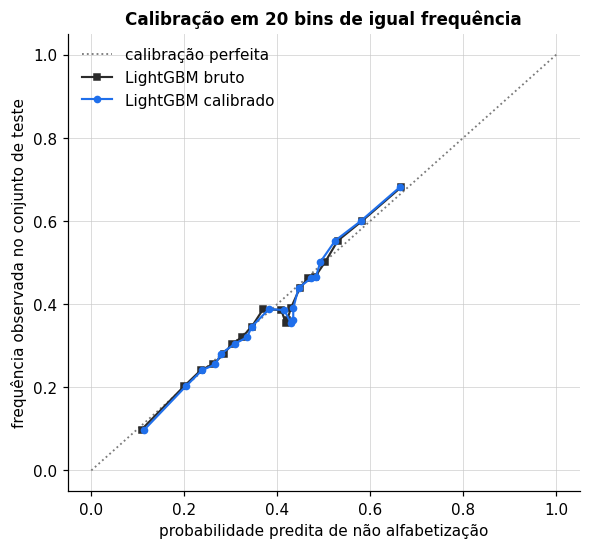

In [8]:
curva = pd.read_csv(config.DIR_METRICS / "campeao_calibracao.csv")
fig = plots.plotar_curva_calibracao(curva)
print(plots.salvar_figura(fig, "02_curva_calibracao"))

 fracao_atendida  n_atendidos  recall  precisao   lift
            0.05        16542  0.0894    0.6814 1.7872
            0.10        33084  0.1680    0.6405 1.6799
            0.20        66167  0.3062    0.5837 1.5311
            0.30        99251  0.4277    0.5436 1.4257
            0.40       132334  0.5364    0.5113 1.3410
            0.50       165418  0.6301    0.4805 1.2603


images/modelagem/03_capacidade.png


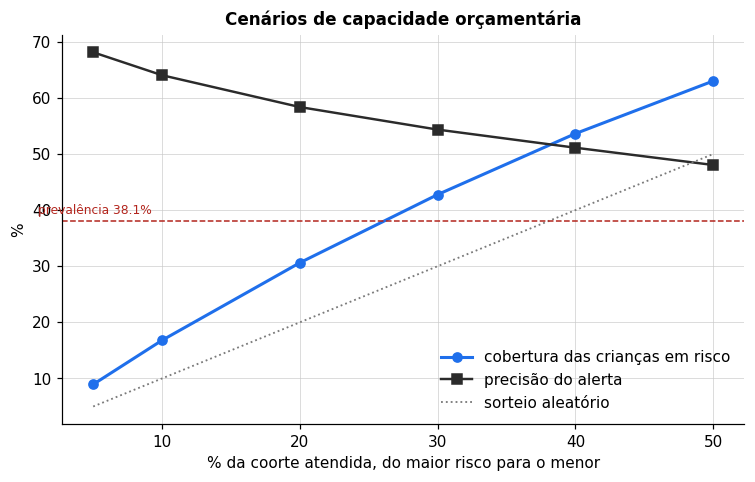

In [9]:
capacidade = pd.read_csv(config.DIR_METRICS / "campeao_capacidade.csv")
print(capacidade.round(4).to_string(index=False))
fig = plots.plotar_capacidade(capacidade, metricas["teste"]["publicado"]["prevalencia"])
print(plots.salvar_figura(fig, "03_capacidade"))

**Achado 8, a calibração foi testada e rejeitada pelo próprio critério.** Ajustar a isotônica nos escores out-of-fold e medi-la **nos mesmos escores** garantiria ganho por construção — é o erro que a comparação circular sempre comete. Ajustando em quatro folds e medindo no quinto, o Brier vai de **0,22233 cru para 0,22244 calibrado**: a isotônica piora, em 1,1e-4. O LightGBM treinado com logloss numa base de prevalência 0,40 já sai calibrado, e a etapa só acrescenta ruído. O artefato serializado é o modelo cru; a curva isotônica fica gravada dentro dele, desligada, para quem quiser reabrir a decisão.

**Achado 9, o limiar de máximo F1 é matematicamente correto e operacionalmente inútil.** Ele cai em 0,297 e alerta **74,1% da coorte** — recall 0,852, precisão 0,438. Com prevalência de 0,38 e ranking fraco, maximizar F1 sempre empurra o corte para baixo até quase alertar todo mundo, o que não é uma política pública, é uma constatação. O limiar que a entrega publica é o **de capacidade**: cortando nos 20% de maior risco do desenvolvimento, o corte fica em 0,525, alerta 13,0% do teste e captura 21,1% das crianças em risco com precisão de 0,620 — **1,63 vez** a prevalência. Os dois vão no relatório, e a curva inteira vai junto para que quem tem o orçamento escolha outro ponto.

---
## 5. A única passagem pelo conjunto de teste

**Pergunta:** qual é o desempenho esperado em municípios que o modelo nunca viu?
**Decisão:** publicar o número, com incerteza, ou voltar uma fase.

O teste foi separado antes de qualquer exploração desta etapa e escorado uma vez só. Limiar, hiperparâmetros, calibração e escolha de família saíram todos do desenvolvimento.

In [10]:
ic = pd.DataFrame(metricas["teste"]["intervalos_bootstrap"])
print(ic.round(5).to_string(index=False))
print("\nno limiar de capacidade:")
print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in metricas["teste"]["no_limiar_de_capacidade"].items()})
print("\nno limiar de maximo F1:")
print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in metricas["teste"]["no_limiar"].items()})

metrica  pontual  ic_baixo  ic_alto  desvio_bootstrap  n_reamostras
roc_auc  0.65990   0.63137  0.68531           0.01459          1000
 pr_auc  0.53595   0.50560  0.56717           0.01619          1000
  brier  0.21794   0.21174  0.22321           0.00296          1000

no limiar de capacidade:
{'limiar': 0.5251, 'recall': 0.2106, 'precisao': 0.6201, 'f1': 0.3144, 'especificidade': 0.9205, 'taxa_de_alerta': 0.1295, 'vp': 26560, 'fp': 16270, 'fn': 99568, 'vn': 188438}

no limiar de maximo F1:
{'limiar': 0.2971, 'recall': 0.8518, 'precisao': 0.4382, 'f1': 0.5787, 'especificidade': 0.3271, 'taxa_de_alerta': 0.7411, 'vp': 107442, 'fp': 137742, 'fn': 18686, 'vn': 66966}


In [11]:
decis = pd.read_csv(config.DIR_METRICS / "campeao_decis.csv")
print(decis.round(4).to_string(index=False))

 decil     n   taxa   lift
     1 33084 0.6405 1.6799
     2 33084 0.5269 1.3822
     3 33083 0.4633 1.2151
     4 33084 0.4143 1.0867
     5 33083 0.3571 0.9368
     6 33084 0.3870 1.0152
     7 33083 0.3329 0.8732
     8 33084 0.2919 0.7657
     9 33083 0.2483 0.6512
    10 33084 0.1502 0.3940


**Achado 10, ROC-AUC 0,6599 com IC95 [0,6314; 0,6853].** O intervalo vem de mil reamostragens de **municípios**, não de alunos — reamostrar alunos trataria as 2.700 crianças de uma cidade como 2.700 observações independentes e devolveria um intervalo várias vezes mais estreito e falso. O ponto está dentro da faixa fixada antes de treinar (0,65 ± 0,03), e a largura de 0,054 é o dado desconfortável: **a incerteza do modelo é o dobro do ganho que ele tem sobre a regra de uma variável.**

**Achado 11, o ranking concentra risco de forma útil mas não monotônica.** O decil mais arriscado tem 64,1% de crianças em risco contra 15,0% no menos arriscado — lift de 1,68 contra 0,39, uma razão de 4,3 vezes entre as pontas. No meio da fila a ordenação falha: o decil 6 tem taxa **maior** que o 5 (0,387 contra 0,357). É onde os escores se acumulam e onde a informação municipal não distingue mais nada.

---
## 6. A estratificação obrigatória

**Pergunta:** o número agregado descreve a coorte inteira?
**Decisão:** o que precisa ir estratificado em todo relatório e em todo ranking.

A Etapa 3 deixou isto como contrato: `tem_historico_municipio` separa SP, DF e AC do resto (B3), e `fonte_lag_municipal` diz de qual das três apurações veio cada valor coalescido (B4). Um único número mistura populações.

In [12]:
estratificado = pd.read_csv(config.DIR_METRICS / "campeao_estratificado.csv")
for dimensao in ["tem_historico_municipio", "fonte_lag_municipal", "tem_lag_de_uf"]:
    print(estratificado[estratificado["dimensao"] == dimensao].round(4).to_string(index=False), "\n")

               dimensao estrato      n  prevalencia  roc_auc  pr_auc     ks  brier
tem_historico_municipio       1 286358       0.3776   0.6706  0.5436 0.2358 0.2148
tem_historico_municipio       0  44478       0.4050   0.5718  0.4602 0.1207 0.2378 

           dimensao       estrato      n  prevalencia  roc_auc  pr_auc     ks  brier
fonte_lag_municipal          gold 286358       0.3776   0.6706  0.5436 0.2358 0.2148
fonte_lag_municipal   agregado_r3  23522       0.3876   0.5598  0.4387 0.0973 0.2363
fonte_lag_municipal   agregado_r5  19727       0.4228   0.5846  0.4863 0.1506 0.2389
fonte_lag_municipal sem_historico   1229       0.4516   0.5227  0.4739 0.0575 0.2501 

     dimensao    estrato      n  prevalencia  roc_auc  pr_auc     ks  brier
tem_lag_de_uf demais_ufs 329636       0.3810   0.6602  0.5361 0.2220 0.2178
tem_lag_de_uf    AC_e_DF   1200       0.4542   0.5173  0.4740 0.0531 0.2515 



images/modelagem/04_estratificado_fonte_lag_municipal.png


images/modelagem/04_estratificado_quintil_presenca_municipal.png


images/modelagem/04_estratificado_nome_regiao.png


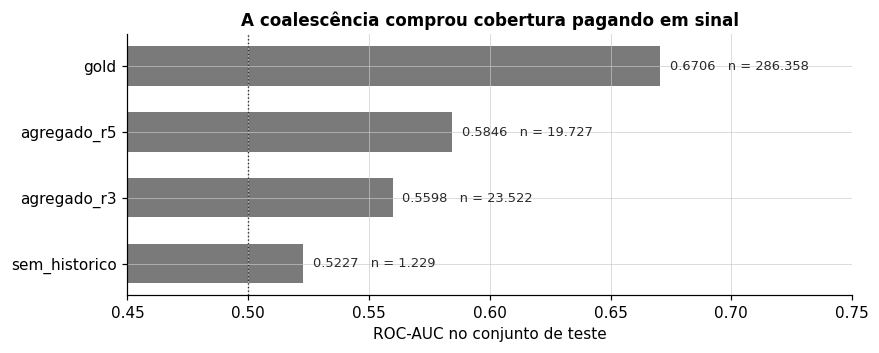

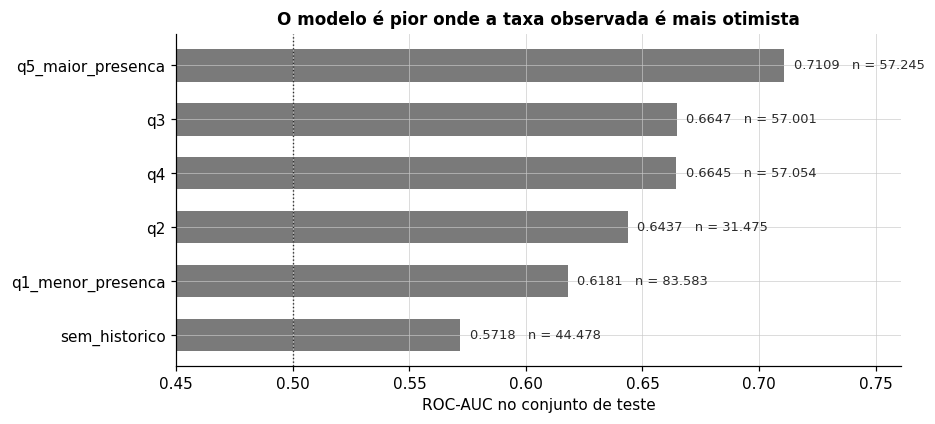

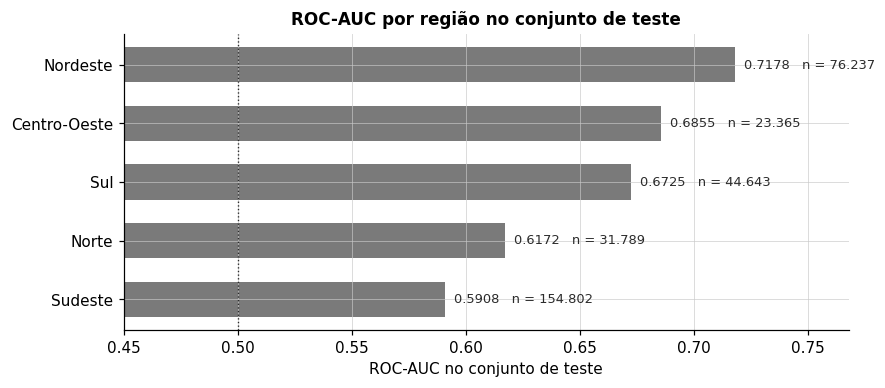

In [13]:
for dimensao, titulo in [
    ("fonte_lag_municipal", "A coalescência comprou cobertura pagando em sinal"),
    ("quintil_presenca_municipal", "O modelo é pior onde a taxa observada é mais otimista"),
    ("nome_regiao", "ROC-AUC por região no conjunto de teste"),
]:
    fig = plots.plotar_estratificado(estratificado, dimensao, titulo)
    print(plots.salvar_figura(fig, f"04_estratificado_{dimensao}"))

In [14]:
print(estratificado[estratificado["dimensao"] == "quintil_presenca_municipal"].round(4).to_string(index=False))
print()
print(estratificado[estratificado["dimensao"] == "nome_regiao"].round(4).to_string(index=False))

                  dimensao           estrato     n  prevalencia  roc_auc  pr_auc     ks  brier
quintil_presenca_municipal q1_menor_presenca 83583       0.4234   0.6181  0.5502 0.1947 0.2334
quintil_presenca_municipal q5_maior_presenca 57245       0.2948   0.7109  0.4970 0.3083 0.1836
quintil_presenca_municipal                q4 57054       0.3255   0.6645  0.4829 0.2471 0.2030
quintil_presenca_municipal                q3 57001       0.4085   0.6647  0.5734 0.2433 0.2215
quintil_presenca_municipal     sem_historico 44478       0.4050   0.5718  0.4602 0.1207 0.2378
quintil_presenca_municipal                q2 31475       0.4447   0.6437  0.5699 0.2288 0.2319

   dimensao      estrato      n  prevalencia  roc_auc  pr_auc     ks  brier
nome_regiao      Sudeste 154802       0.3515   0.5908  0.4335 0.1210 0.2232
nome_regiao     Nordeste  76237       0.4264   0.7178  0.6207 0.3012 0.2087
nome_regiao          Sul  44643       0.3702   0.6725  0.5287 0.2815 0.2127
nome_regiao        Norte  3178

**Achado 12, o 0,6599 agregado é a média de três populações muito diferentes.** Onde o histórico vem da Gold — 286 mil alunos, 86,6% do teste — a AUC é **0,6706**. Onde ele veio do agregado do INEP na rede 5, **0,5846**; na rede 3, **0,5598**; e onde não há histórico, **0,5227**, que é o acaso. A coalescência `5 → 3` da Etapa 3 levou a cobertura de 76,9% para 98,1%, e este é o preço que ela cobrou: os 13,4% de alunos resgatados entram no modelo com um sinal quase três vezes mais fraco. Foi um bom negócio — sem ela São Paulo inteira ficaria sem feature —, mas o número agregado não pode ser apresentado como se valesse igualmente para todos.

**Achado 13, Acre e Distrito Federal são ruído.** Os 1.200 alunos do teste sem lag de UF nenhum marcam AUC **0,5173**. Nenhuma fonte de 2023 os cobre, e o modelo não tem o que dizer sobre eles. Qualquer ranking publicado na Etapa 6 precisa marcá-los como não avaliados em vez de posicioná-los.

**Achado 14, o modelo é pior exatamente onde o problema é maior.** Nos municípios do quintil de **menor** taxa de presença em 2023, a AUC é 0,6181 e a prevalência de risco 0,4234; no quintil de maior presença, AUC 0,7109 com prevalência 0,2948. A EDA já havia medido que a taxa observada é otimista onde a presença é baixa; agora se soma que o modelo também erra mais ali. Os dois vieses apontam para o mesmo lado — subestimar o problema onde ele é pior — e o ranking municipal precisa carregar a taxa de presença ao lado.

**Achado 15, o Sudeste é a região mais difícil e a maior.** AUC 0,5908 em 154.802 alunos, quase metade do teste, contra 0,7178 no Nordeste. Não é coincidência: São Paulo é a maior parte do Sudeste e é justamente quem depende do agregado coalescido em vez do microdado. As duas estratificações contam a mesma história por caminhos diferentes.

---
## 7. O grão municipal

**Pergunta:** o escore individual sobrevive à agregação que a decisão de política usa?
**Decisão:** se a camada estratégica da Etapa 6 pode se apoiar neste modelo.

A decisão não é sobre uma criança, é sobre um município. Uma AUC de 0,66 no grão aluno pode conviver com uma ordenação municipal muito melhor, porque a média cancela o ruído individual.

 porte_minimo  n_municipios     r2  correlacao  vies_medio
            0          1104 0.6237      0.7904     -0.0056
           50           865 0.7074      0.8412     -0.0026
          200           355 0.7743      0.8809     -0.0051


images/modelagem/05_risco_municipal.png


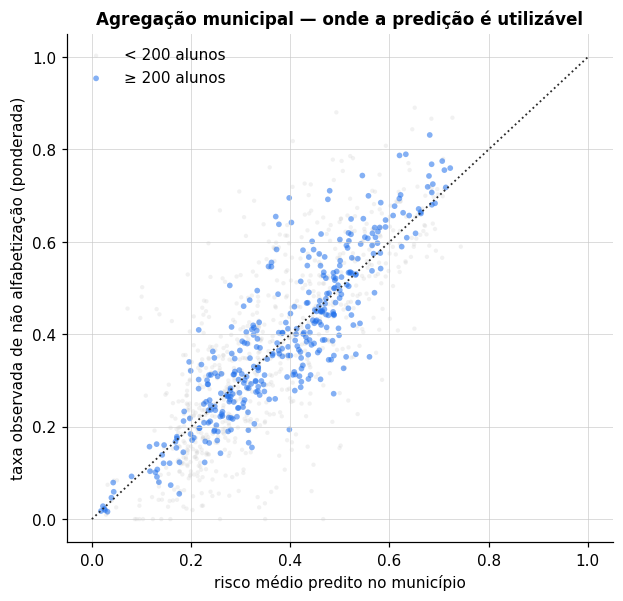

In [15]:
r2 = pd.read_csv(config.DIR_METRICS / "campeao_r2_municipal.csv")
print(r2.round(4).to_string(index=False))

pacote = campeao.carregar_campeao()
escore_teste = pacote["modelo"].predict_proba(X.iloc[teste])[:, 1]
municipal = mt.agregar_por_municipio(
    y.iloc[teste], escore_teste, grupos.iloc[teste], dados[config.COL_PESO].iloc[teste]
)
fig = plots.plotar_risco_municipal(municipal)
print(plots.salvar_figura(fig, "05_risco_municipal"))

**Achado 16, o modelo é bem melhor no grão em que a decisão acontece.** Nos 1.104 municípios do teste, o risco médio predito explica **R² 0,624** da taxa observada, com correlação de 0,790. Restringindo aos 355 municípios com 200 ou mais alunos avaliados — onde a taxa observada é ela mesma confiável —, o R² sobe para **0,774** e a correlação para 0,881. O viés médio é de −0,4pp, ou seja, o modelo subestima levemente o risco.

Isto é a resposta técnica ao desconforto do Achado 3: a AUC de 0,66 no aluno e o R² de 0,78 no município não são contraditórios, são a mesma informação em dois grãos. O território explica bem o território e explica mal a criança — que é, em si, o achado de política pública desta entrega.

---
## 8. As provas de rigor

**Pergunta:** o número significa alguma coisa, ou é variância bem apresentada?
**Decisão:** publicar, iterar ou encerrar.

Cinco provas, cada uma respondendo a uma pergunta diferente sobre o mesmo número.

                    nulo  n_permutacoes  roc_auc_real  nulo_media  nulo_dp  nulo_maximo  p_valor
             nulo_global             50       0.66665     0.50008  0.00159      0.50363  0.01961
nulo_dentro_do_municipio             20       0.66665     0.66359  0.00030      0.66406  0.04762


images/modelagem/06_permutacao.png


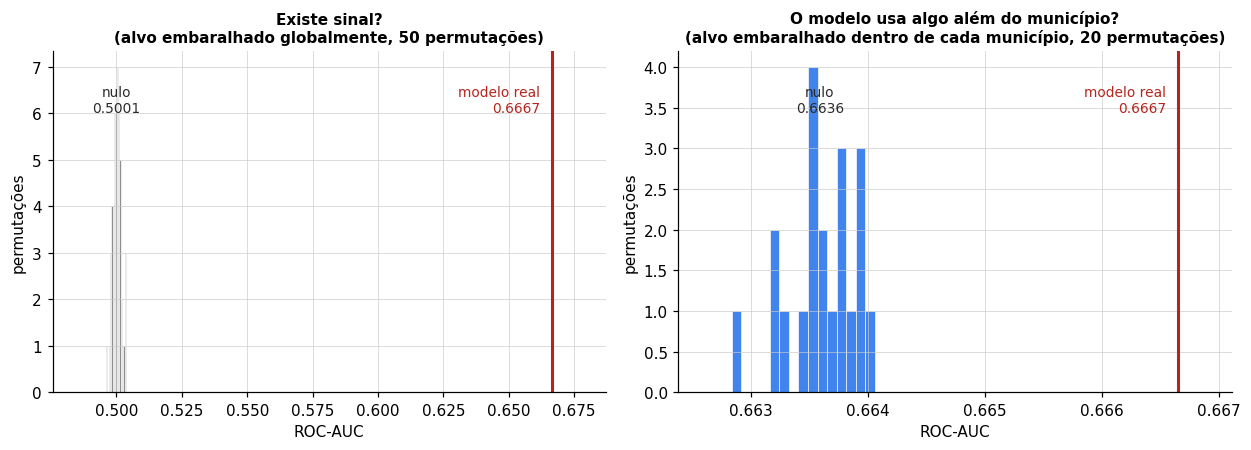

In [16]:
permutacao = pd.read_csv(config.DIR_METRICS / "rigor_permutacao.csv")
print(rigor.resumo_da_permutacao(permutacao).round(5).to_string(index=False))
fig = plots.plotar_permutacao(permutacao)
print(plots.salvar_figura(fig, "06_permutacao"))

        municipios        alunos  treino  validacao  validacao_dp
fracao                                                           
0.02       79.0000  2.527533e+04  0.6535     0.6493        0.0103
0.05      204.3333  5.840833e+04  0.6722     0.6560        0.0035
0.10      409.3333  1.182570e+05  0.6883     0.6651        0.0033
0.25      979.0000  2.891527e+05  0.6803     0.6687        0.0015
0.50     1735.3333  6.014683e+05  0.6727     0.6715        0.0007
0.75     2369.6667  8.673063e+05  0.6719     0.6723        0.0004
1.00     3309.0000  1.155906e+06  0.6700     0.6726           NaN


images/modelagem/07_curva_aprendizado.png


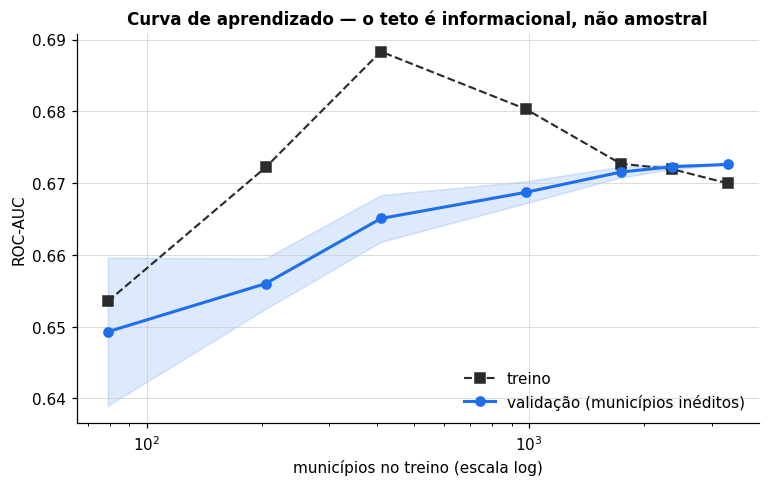

In [17]:
aprendizado = pd.read_csv(config.DIR_METRICS / "rigor_curva_aprendizado.csv")
print(
    aprendizado.groupby("fracao")
    .agg(municipios=("n_municipios_treino", "mean"), alunos=("n_alunos_treino", "mean"),
         treino=("roc_auc_treino", "mean"), validacao=("roc_auc_validacao", "mean"),
         validacao_dp=("roc_auc_validacao", "std"))
    .round(4)
    .to_string()
)
fig = plots.plotar_curva_de_aprendizado(aprendizado)
print(plots.salvar_figura(fig, "07_curva_aprendizado"))

                   desenho  n_treino  n_teste  prevalencia_teste  roc_auc  dp_entre_folds
2023 -> 2023 (CV agrupada)   1502809  1502809             0.4161   0.6359          0.0085
2024 -> 2024 (CV agrupada)   1851852  1851852             0.4022   0.6306          0.0084
2023 -> 2024 (out-of-time)   1502809  1851852             0.4022   0.6099             NaN 

regiao_de_teste  n_treino  n_teste  prevalencia_teste  roc_auc  segundos
   Centro-Oeste   1369176   151840             0.3605   0.6130      18.2
       Nordeste   1131765   389251             0.4324   0.7124      17.5
          Norte   1364686   156330             0.4930   0.5814      17.8
        Sudeste    931181   589835             0.3838   0.6179      15.0
            Sul   1287256   233760             0.3941   0.6196      17.6


images/modelagem/08_drift_e_logo.png


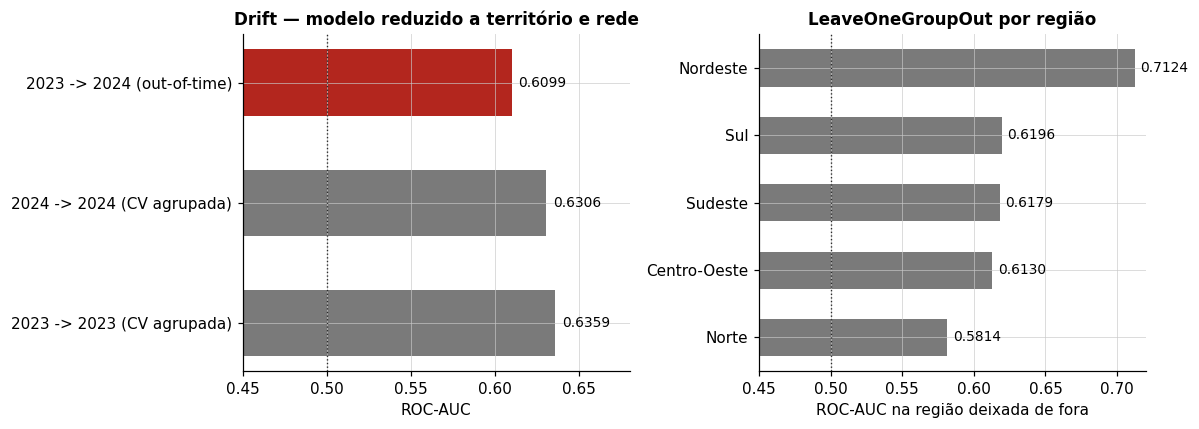

In [18]:
drift = pd.read_csv(config.DIR_METRICS / "rigor_drift.csv")
logo = pd.read_csv(config.DIR_METRICS / "rigor_logo_regiao.csv")
print(drift.round(4).to_string(index=False), "\n")
print(logo.round(4).to_string(index=False))
fig = plots.plotar_drift_e_logo(drift, logo)
print(plots.salvar_figura(fig, "08_drift_e_logo"))

In [19]:
print(pd.read_csv(config.DIR_METRICS / "rigor_invariancia.csv").round(5).to_string(index=False))

                  coluna  roc_auc_referencia  queda_media  queda_dp  n_repeticoes
                 caderno              0.6599      0.00031   0.00007             5
mun_media_portugues_lag1              0.6599      0.04203   0.00082             5
              rede_grupo              0.6599      0.00285   0.00021             5


**Achado 17, o sinal existe, e o segundo nulo diz o que ele é.** Embaralhar o alvo globalmente joga a AUC para 0,5001 com desvio de 0,0016; o modelo real está a mais de cem desvios dali. O p de 0,020 é o menor valor observável com 50 permutações, não a força do efeito. A segunda linha é a que informa: embaralhando o alvo **dentro de cada município** — o que preserva a taxa municipal exata e destrói todo o resto — a AUC cai de 0,6667 para apenas **0,6636**.

**Tudo o que o modelo sabe além da taxa média do seu município vale 0,0031 de ROC-AUC.** É detectável, porque o real supera as vinte permutações e o desvio do nulo é 0,0003, e é irrelevante para qualquer decisão. Vinte features, uma busca de hiperparâmetros e 883 árvores estão, em 99,5% da sua capacidade discriminante, reproduzindo uma média por município. Isso não invalida o modelo — reenquadra: o objeto que esta base permite construir é um medidor de risco **territorial**, e a Etapa 6 está certa em levá-lo para o grão municipal. O que ele não é, e não pode ser vendido como, é um identificador de crianças em risco dentro de uma mesma escola.

**Achado 18, o teto é informacional e não amostral.** De 979 para 3.309 municípios — 3,4 vezes mais dado — a validação sobe 0,0039, de 0,6687 para 0,6726. Dobrar a base compraria algo em torno de 0,002, contra os 0,027 que separam o modelo da regra de uma variável. Mais crianças das mesmas variáveis não resolvem; variáveis novas sobre a criança resolveriam. O gap treino−validação conta a outra metade: é máximo em 409 municípios (0,023) e **negativo** com a base inteira (−0,0026). O modelo escolhido pela busca é regularizado a ponto de não conseguir sobreajustar 1,2 milhão de linhas — não há overfitting a combater aqui, há informação faltando.

**Achado 19, generaliza para região nova, de forma desigual.** Nenhuma das cinco regiões cai para o acaso quando é deixada inteira fora do treino, o que já é informativo: a relação existe fora do território onde foi aprendida. Mas a amplitude é de 0,131, do Nordeste (0,7124) ao Norte (0,5814) — muito maior que o desvio entre folds do desenho normal. O Norte merece a leitura completa: é a região de maior prevalência de risco (0,493 contra 0,361 no Centro-Oeste) e de faixa mais estreita, então parte da queda é propriedade da população. Ainda assim, 0,58 é fraco em termos absolutos, e um programa nacional que use este escore no Norte precisa saber disso.

**Achado 20, a estrutura territorial se desloca entre edições.** O modelo reduzido a UF, região e rede marca 0,6359 dentro de 2023 e 0,6306 dentro de 2024, mas apenas **0,6099 quando treinado em 2023 e testado em 2024**. A queda de 0,0207 contra a referência do próprio ano é maior que o ganho do modelo completo sobre a regra de uma variável. Duas consequências: o modelo precisa de **retreino anual**, e é isso que o plano de monitoramento tem de vigiar; e o ranking de 2024 descreve 2024, de modo que usá-lo para planejar 2026 sem reestimar assumiria uma estabilidade que a medição desmente. Vale notar de passagem que três colunas territoriais já valem 0,63 dentro do mesmo ano, contra 0,66 do modelo completo.

**Achado 21, os dois controles se comportaram.** Embaralhar o `caderno` move a AUC em 0,00031, contra 0,04203 do controle positivo `mun_media_portugues_lag1` — 135 vezes menos. A queda não é exatamente zero (com 1,85 milhão de linhas qualquer coisa é detectável, e 0,00031 está a 4,4 desvios de zero), mas é pequena o bastante para o `caderno` seguir como controle negativo declarado. O controle positivo é o que prova que o teste tem sensibilidade: sem ele, uma queda nula em toda coluna seria indistinguível de um teste quebrado.

---
## 9. O que a Etapa 5 recebe

**Pergunta:** o que fica pronto, e com que ressalvas a interpretabilidade tem de trabalhar?
**Decisão:** o contrato da etapa seguinte.

In [20]:
print("artefato:", campeao.MODELO_CAMPEAO.relative_to(config.ROOT))
print("chaves   :", sorted(pacote))
print("colunas apos o pre-processador:", len(pacote["nomes_apos_pre_processamento"]))
print("versoes  :", pacote["versoes"])
print("hash do dataset:", pacote["hash_dataset"])
print("\nprimeiras 12 colunas que chegam ao estimador:")
print(pacote["nomes_apos_pre_processamento"][:12])

artefato: models\campeao.joblib
chaves   : ['features', 'hash_dataset', 'limiar_por_capacidade', 'limiar_por_f1', 'modelo', 'nomes_apos_pre_processamento', 'seed', 'status_validacao', 'versoes']
colunas apos o pre-processador: 89
versoes  : {'sklearn': '1.8.0', 'lightgbm': '4.7.0'}
hash do dataset: cc2215565c04d14a5ad97dbfcdda31b5

primeiras 12 colunas que chegam ao estimador:
['mun_taxa_alfab_lag1', 'mun_media_portugues_lag1', 'mun_nivel_alfabetizacao_lag1', 'mun_meta_2024_lag1', 'mun_taxa_presenca_lag1', 'mun_n_alunos_lag1', 'mun_n_escolas_lag1', 'mun_share_rede_estadual_lag1', 'mun_desvio_vs_uf', 'uf_taxa_alfab_lag1', 'uf_media_portugues_lag1', 'uf_taxa_presenca_lag1']


**O contrato.** `models/campeao.joblib` guarda o `ModeloCalibrado` — que recebe a linha como ela sai de `data/processed/dataset_2024.parquet` e devolve `P(risco_nao_alfabetizacao)` —, os dois limiares, os nomes das **89 colunas** que chegam ao estimador depois do `ColumnTransformer`, a seed, o hash do dataset e as versões de `scikit-learn` e `lightgbm`. Os escores out-of-fold do desenvolvimento ficam em `models/escores_oof_desenvolvimento.parquet`, prontos para o ranking municipal da Etapa 6 sem contaminação.

**Quatro ressalvas que a Etapa 5 herda:**

1. **Ler SHAP por família, não por coluna.** As vinte features têm treze pares com |Spearman| acima de 0,95 e três combinações lineares exatas. Crédito distribuído entre colunas que dizem a mesma coisa não é achado sobre alfabetização, é artefato de codificação.
2. **`caderno` é controle negativo e se comportou como tal** — queda de 0,0003 contra 0,042 do controle positivo. Se ele aparecer alto no SHAP, o alarme é de sobreajuste. O bloco `esc_*` é o segundo controle negativo, por ablação, e está fora do modelo.
3. **A importância vale muito mais para 86,6% da coorte que para o resto.** Qualquer leitura global mistura a fatia de AUC 0,671 com a de 0,523. O SHAP precisa ser lido também dentro de `fonte_lag_municipal = gold`.
4. **Importância não é causalidade.** O SHAP diz o que o modelo usou para prever, não o que aconteceria se alguém interviesse na variável. Em política educacional essa confusão vira recomendação errada, e as features aqui são todas contextuais — falácia ecológica é o risco imediato.